# Lecture 6: Exercise 1 — Solution

## Objective

Analyze social network data to predict romantic relationships based on friendship connections and user features. We compute absolute differences between friend pairs, build a prediction model, and interpret the results.

## Data

- **vertices.csv**: User-level variables (demographics, activity counts, like categories).
- **edges_friends.csv**: Pairs of users who are friends.
- **edges_relationship.csv**: Pairs of users in romantic relationships.

## Tasks

- For all users (`uid`) in `edges_friends`, compute the **absolute differences** for each variable in `vertices` between friends. Each row represents a pair of users.
- Use these computed differences to **predict romantic relationships** (i.e., whether a friendship pair also appears in `edges_relationship`).
- **Train a prediction model** of your choice to classify relationships.
- **Evaluate** model performance using AUC.
- Plot the **feature importances** to understand which attributes are most influential.
- Create **Partial Dependence Plots** (PDPs) for the most important predictors.
- **Interpret** the results.

> **Challenge:** Want to go beyond the default permutation feature importance? Try implementing **SHAP** to get a more accurate interpretation of feature importance!

## Solution

This solution builds a social network analysis pipeline to predict romantic relationships from friendship pairs. The key steps are:

- **Feature engineering**: Compute pairwise absolute differences between user attributes for all friend pairs, encoding *homophily* as a numeric signal.
- **Model**: XGBoost classifier with class-imbalance correction via `scale_pos_weight`.
- **Evaluation**: AUC on a held-out test set
- **Interpretability**: Built-in gain importance → permutation importance → Partial Dependence Plots → SHAP values, providing increasingly reliable explanations.

**Key implementation details:**
- **Symmetric target construction**: The relationship label is derived by cross-referencing `edges_friends` with `edges_relationship` lookup.
- **Class imbalance**: Handled via `scale_pos_weight` in XGBoost rather than resampling, to avoid data leakage.

### Step 1: Import Libraries and Configure Environment

Import all required packages and set global random seeds for reproducibility.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from xgboost import XGBClassifier

# Settings
np.random.seed(123)

print("✓ All packages loaded successfully!")

✓ All packages loaded successfully!


### Step 2: Load and Explore Data

Load the social network dataset. The data comes in three separate files:

- **vertices.csv**: Node-level attributes for each user, such as demographics (age, gender) and activity metrics (number of likes per category).
- **edges_friends.csv**: Directed pairs of users who are friends (`uid`, `friend_id`).
- **edges_relationship.csv**: Directed pairs of users in a romantic relationship (`uid`, `friend_id`).

**Important pre-processing detail**: All `uid` columns are cast to strings before any join operations to prevent silent type-mismatch bugs (e.g., integer `123` vs string `"123"` failing to match in a set lookup).

In [3]:
# Load the three dataset files
vertices = pd.read_csv('Data/vertices.csv')
edges_friends = pd.read_csv('Data/edges_friends.csv')
edges_relationship = pd.read_csv('Data/edges_relationship.csv')

# Convert uid columns to string to prevent integer/string type-mismatch during set lookups
vertices['uid'] = vertices['uid'].astype(str)
edges_friends = edges_friends.astype(str)
edges_relationship = edges_relationship.astype(str)

print(f"Vertices: {vertices.shape}")
print(f"Friend edges: {edges_friends.shape}")
print(f"Relationship edges: {edges_relationship.shape}")
vertices.head()

Vertices: (1583, 203)
Friend edges: (1090, 2)
Relationship edges: (143, 2)


,uid,genderfemale,age,NBRlikes,NBRvideos,NBRgroups,NBRsports,NBRtelevision,NBRmusic,NBRmovies,...,like_cat179,like_cat180,like_cat181,like_cat182,like_cat183,like_cat184,like_cat185,like_cat186,like_cat187,like_cat188
0,100000028948428,1,6333.0,5,0,60,1,25,25,10,...,0,0,0,0,0,0,0,0,0,0
1,100000043924015,0,7434.0,1,0,4,0,2,1,1,...,0,0,0,0,0,0,0,0,0,0
2,100000056065350,0,11527.0,1,0,6,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
3,100000065070864,0,7146.0,0,0,14,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,100000070565512,0,6424.0,3,0,20,1,25,25,10,...,0,0,0,0,0,0,0,0,0,0


### Step 3: Feature Engineering — Pairwise Absolute Differences

The core insight is that **raw user attributes** are not directly predictive: what matters is *how similar or different* two users are. For each pair of friends `(uid, friend_id)`, we compute the **absolute difference** of every feature in `vertices`.

**Why absolute differences?**
- Pair direction is arbitrary: `(A, B)` and `(B, A)` represent the same friendship, so we need symmetric features.
- Absolute differences satisfy symmetry: |A − B| = |B − A|.
- They directly encode the concept of **homophily** (i.e., the tendency for people to associate with similar others).

**Target variable construction**: A label of **1** is assigned when the friend pair also appears in `edges_relationship` (i.e., they are in a romantic relationship). All other pairs receive label **0**.

In [4]:
# Index vertices by uid for O(1) feature lookup during pair iteration
vertex_features = vertices.set_index('uid').sort_index()

# Build the feature matrix: absolute differences between friend pairs
records = []
labels = []

# Create a set of relationship pairs for O(1) label lookup
# (checking membership in a set is ~100x faster than searching a DataFrame)
rel_set = set(zip(edges_relationship['uid'], edges_relationship['friend_id']))

for _, row in edges_friends.iterrows():
    uid, fid = row['uid'], row['friend_id']
    if uid in vertex_features.index and fid in vertex_features.index:
        # Compute absolute pairwise difference for all features
        diff = (vertex_features.loc[uid] - vertex_features.loc[fid]).abs()
        records.append(diff)
        # Label: 1 if this friendship pair is also in a romantic relationship, 0 otherwise
        labels.append(1 if (uid, fid) in rel_set else 0)

df = pd.DataFrame(records).reset_index(drop=True)
y = pd.Series(labels, name='relationship')

print(f"Feature matrix: {df.shape}")
print(f"\nTarget distribution:\n{y.value_counts().to_string()}")
print(f"\nClass balance: {y.value_counts(normalize=True).round(4).to_string()}")

Feature matrix: (1090, 202)

Target distribution:
relationship
0    947
1    143

Class balance: relationship
0    0.8688
1    0.1312


### Step 4: Train/Test Split

Create a **70/30 train/test split** with stratification across all subsequent models.

We fix `random_state=123` throughout the notebook to ensure full reproducibility.

In [5]:
# Create train/test split (same split reused for all models)
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.3, random_state=123, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size:     {len(X_test)}")
print(f"\nTrain class distribution: {np.bincount(y_train)} (pos rate: {y_train.mean():.3f})")
print(f"Test class distribution:  {np.bincount(y_test)} (pos rate: {y_test.mean():.3f})")

Training set size: 763
Test set size:     327

Train class distribution: [663 100] (pos rate: 0.131)
Test class distribution:  [284  43] (pos rate: 0.131)


### Step 5: Model Training — XGBoost

We train an **XGBoost gradient boosting model** and assess its cross-validated performance before final evaluation.

**Why XGBoost?**
- Handles **non-linear interactions** between pairwise difference features naturally via tree splits.
- Built-in **feature importance** scores (information gain) allow direct model interpretation.
- Efficient and scalable to the relatively high-dimensional feature space produced by pairwise differences.

**Handling class imbalance**:
Since romantic relationships are rare, we set `scale_pos_weight = n_negatives / n_positives`. This directs XGBoost to penalise misclassification of the minority class more heavily which is equivalent to upweighting positive samples during training.

Note that in the paper resampling (SMOTE, random oversampling, undersampling) was applied on the the **training folds** only, not the test folds. However, `scale_pos_weight` is the more elegant solution here for several reasons:

- **No distribution shift**: Oversampling artificially inflates the proportion of positive samples in the training set, changing the joint distribution the model learns. `scale_pos_weight` leaves the training data untouched and instead adjusts the loss function directly.
- **No duplicate labels**: Oversampling with repetition (or synthetic generation via SMOTE) creates highly identical (similiar for SMOTE) training instances. This can lead to overly optimistic performance estimates.
- **Resampling doesn't help strong classifiers**: Undersampling discards potentially informative majority-class examples. For powerful, high-capacity models like XGBoost, this information loss typically *hurts* performance (unlike with simpler models where removing ambiguous majority examples can actually help the decision boundary). Oversampling methods similarly don't translate well here: XGBoost already captures complex non-linear boundaries that benefit from the full training distribution.

**Key hyperparameters**:
- `n_estimators=200`: Number of boosting rounds (trees).
- `learning_rate=0.1`: Step size shrinkage per round to prevent overfitting.
- `max_depth=6`: Maximum tree depth, controlling model complexity.
- `eval_metric='auc'`: Optimise for AUC during training (consistent with our evaluation metric).

> **Challenge:** The hyperparameters above were chosen based on reasonable defaults, but they are not necessarily optimal for this dataset. Use `GridSearchCV` with stratified k-fold cross-validation to search over a grid of key parameters.

In [6]:
# Compute class-imbalance correction factor:
# scale_pos_weight = n_negatives / n_positives tells XGBoost to upweight the minority class
scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight: {scale:.2f}  (1 positive sample = {scale:.1f} negative samples)")

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=123,
    verbosity=0
)

print("✓ Model configured successfully!")

scale_pos_weight: 6.63  (1 positive sample = 6.6 negative samples)
✓ Model configured successfully!


### Step 6: Model Evaluation

Fit the final model on the full training set and evaluate on the held-out test set.

**Why not accuracy?**
With heavily imbalanced classes, a naïve model that predicts "not a romantic relationship" for every pair would achieve ~99% accuracy yet have zero predictive value.

In [7]:
# Fit the final model on the full training set
xgb.fit(X_train, y_train)

# Predict probabilities on the held-out test set
pred_proba = xgb.predict_proba(X_test)[:, 1]  # Probability of class 1 (romantic relationship)
auc = roc_auc_score(y_test, pred_proba)

print(f"Test AUC: {auc:.4f}")

Test AUC: 0.8080


### Step 7: Feature Importance

We compare **two complementary importance metrics**:

1. **Built-in XGBoost importance (Gain)**: Measures the average improvement in the loss function each time a feature is used in a split, summed over all trees. Fast to compute but can be biased towards high-cardinality numeric features that offer many split points.
2. **Permutation importance**: Measures the drop in test AUC when a feature's values are randomly shuffled. Because it evaluates actual predictive contribution on unseen data, it is more reliable and less susceptible to cardinality bias.

Using both together gives a more robust image: features that rank highly on *both* metrics can be considered genuinely important.

#### Built-in XGBoost Importance (Gain)

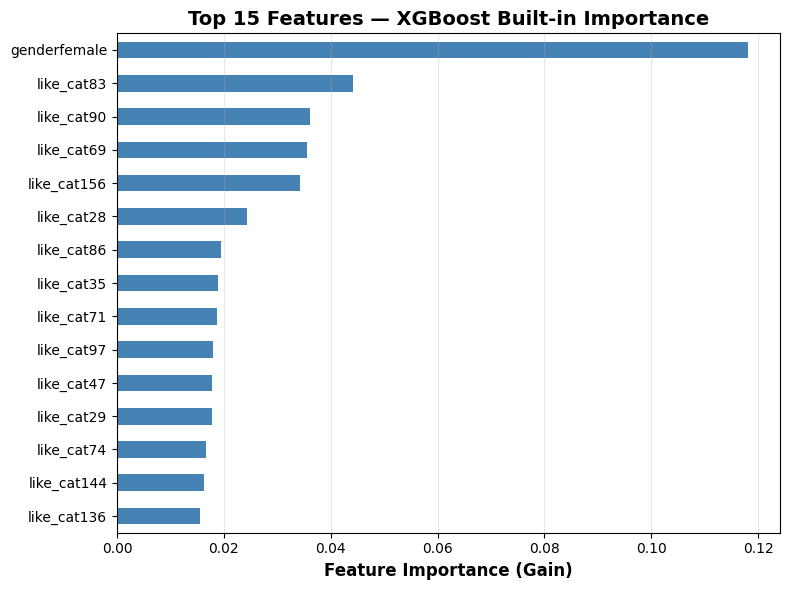

In [8]:
# Extract and plot built-in XGBoost feature importance (Gain metric)
# Gain = average improvement in the loss function per split using that feature
feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns).nlargest(15)

plt.figure(figsize=(8, 6))
feat_imp.sort_values().plot.barh(color='steelblue')
plt.xlabel('Feature Importance (Gain)', fontsize=12, fontweight='bold')
plt.title('Top 15 Features — XGBoost Built-in Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### Permutation Importance (AUC-based)

Permutation importance evaluates each feature by **randomly shuffling its values** across the test set and measuring the resulting drop in AUC. A large drop indicates the model relies heavily on that feature for correct predictions.

**Advantage over built-in importance**: Because it measures the actual impact on held-out performance rather than training-time split statistics, it is less susceptible to bias from high-cardinality features. It is also model-agnostic: the same method works for any sklearn-compatible estimator.

We repeat the permutation `n_repeats=10` times and report the mean and standard deviation across repetitions.

Computing permutation importance (this may take ~30 seconds)...


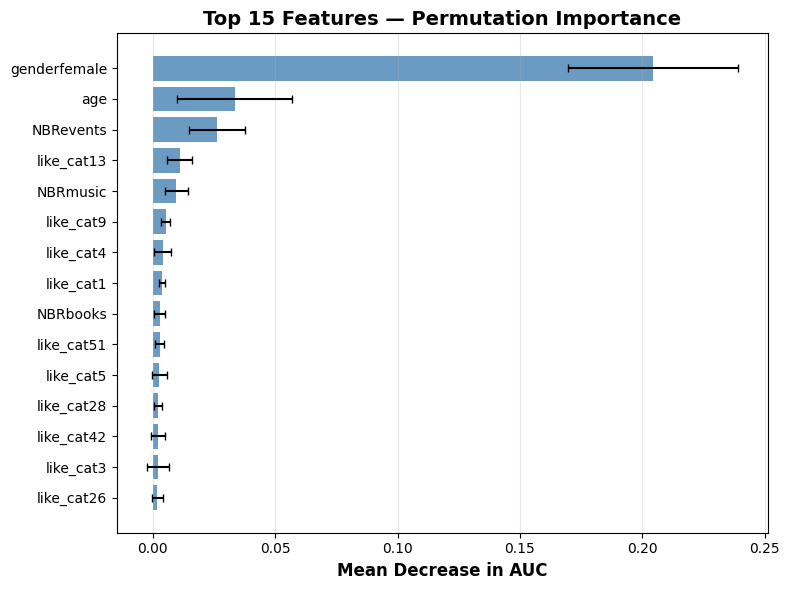

In [9]:
# Compute permutation importance on the test set
# n_repeats=10: shuffle each feature 10 times and average the AUC drop
print("Computing permutation importance (this may take ~30 seconds)...")

perm_imp = permutation_importance(
    xgb, X_test, y_test, n_repeats=10, scoring='roc_auc', random_state=123
)

# Organise results into a DataFrame
perm_df = (
    pd.DataFrame({
        'Feature': X_test.columns,
        'Importance': perm_imp.importances_mean,
        'Std': perm_imp.importances_std
    })
    .nlargest(15, 'Importance')
    .sort_values('Importance')
)

plt.figure(figsize=(8, 6))
plt.barh(perm_df['Feature'], perm_df['Importance'],
         xerr=perm_df['Std'], capsize=3, color='steelblue', alpha=0.8)
plt.xlabel('Mean Decrease in AUC', fontsize=12, fontweight='bold')
plt.title('Top 15 Features — Permutation Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Step 8: Partial Dependence Plots (PDPs)

PDPs show the **marginal effect** of a single feature on the predicted probability of a romantic relationship, averaged over all other features in the training set. They answer the question: *"As this pairwise difference increases, how does the predicted probability change on average?"*

We plot PDPs for the **top 4 features from permutation importance**, as these are the most reliably predictive.

Top 4 features for PDPs: ['genderfemale', 'age', 'NBRevents', 'like_cat13']


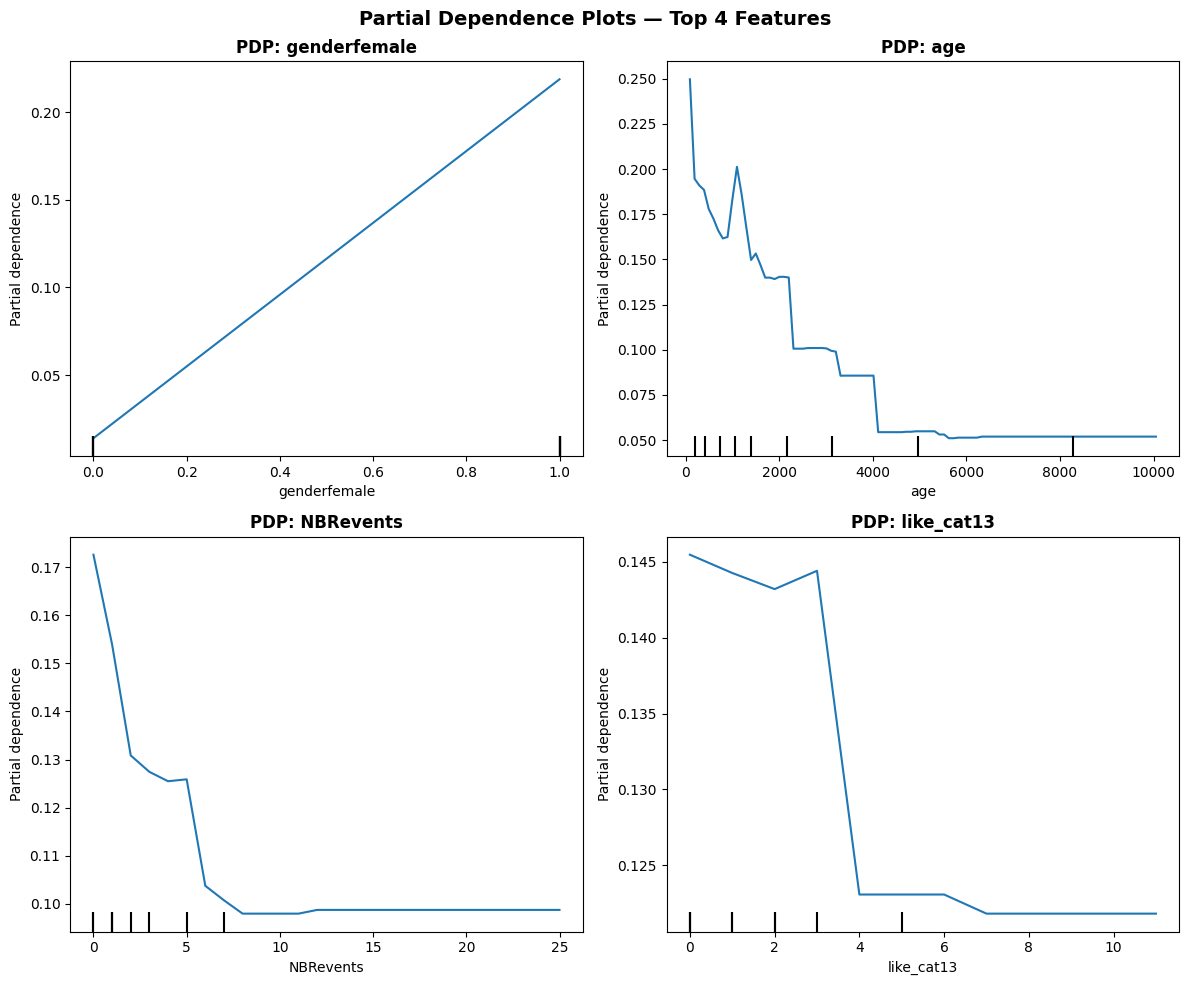

In [10]:
# Retrieve top 4 features from permutation importance for PDP analysis
top_features = perm_df.nlargest(4, 'Importance')['Feature'].tolist()
print(f"Top 4 features for PDPs: {top_features}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feat in zip(axes.ravel(), top_features):
    PartialDependenceDisplay.from_estimator(
        xgb, X_train, features=[feat], target=1, ax=ax
    )
    ax.set_title(f'PDP: {feat}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Absolute difference in {feat}', fontsize=10)
    ax.set_ylabel('Predicted probability', fontsize=10)

plt.suptitle('Partial Dependence Plots — Top 4 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 9: SHAP Analysis (Bonus — Challenge)

**Why SHAP is superior to permutation importance and built-in gain**:
- Provides **per-sample explanations**, not just global averages
- Grounded in **Shapley values** from cooperative game theory: each feature receives a fair share of the credit for the prediction, accounting for all possible feature orderings.
- Shows both the **direction** and **magnitude** of each feature's effect.
- Nice graphical options (e.g., beeswarm plot reveals **effect heterogeneity**)

In [11]:
import shap

# TreeExplainer is optimised for tree-based models (XGBoost, LightGBM, RandomForest)
# It uses the exact TreeSHAP algorithm — much faster than the model-agnostic KernelSHAP
print("Computing SHAP values for test set (TreeSHAP)...")
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"✓ SHAP values computed!")
print(f"  Shape: {shap_values.shape}  (one row per test sample, one column per feature)")

Computing SHAP values for test set (TreeSHAP)...
✓ SHAP values computed!
  Shape: (327, 202)  (one row per test sample, one column per feature)


/var/folders/ft/tnz7yjv95wngxpfm4n16d0ch0000gn/T/ipykernel_92922/4102163091.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)


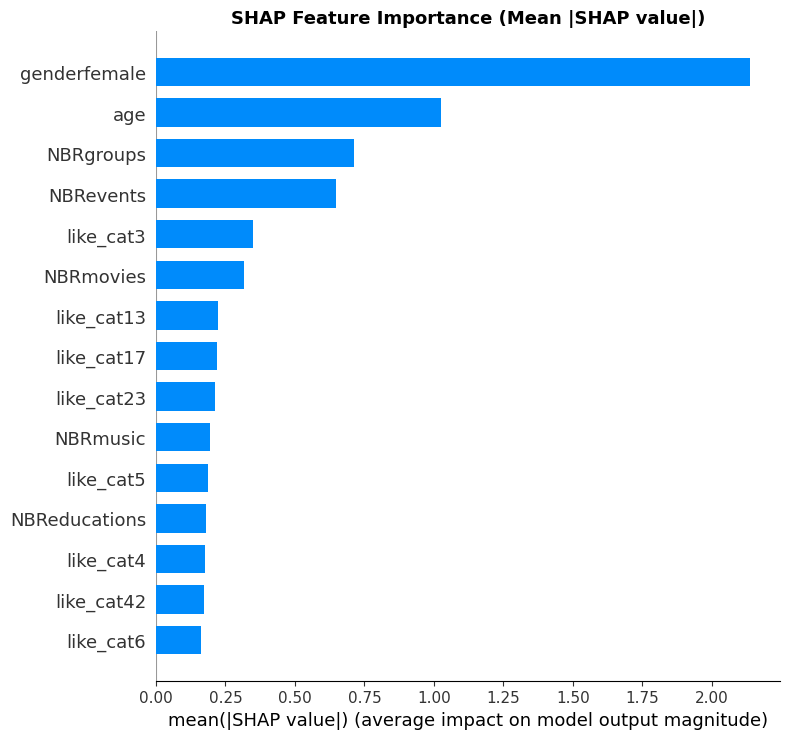

In [12]:
# Global importance bar plot: mean(|SHAP value|) per feature
# Compare with permutation importance — should yield similar top features
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/ft/tnz7yjv95wngxpfm4n16d0ch0000gn/T/ipykernel_92922/1167724490.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, max_display=15, show=False)


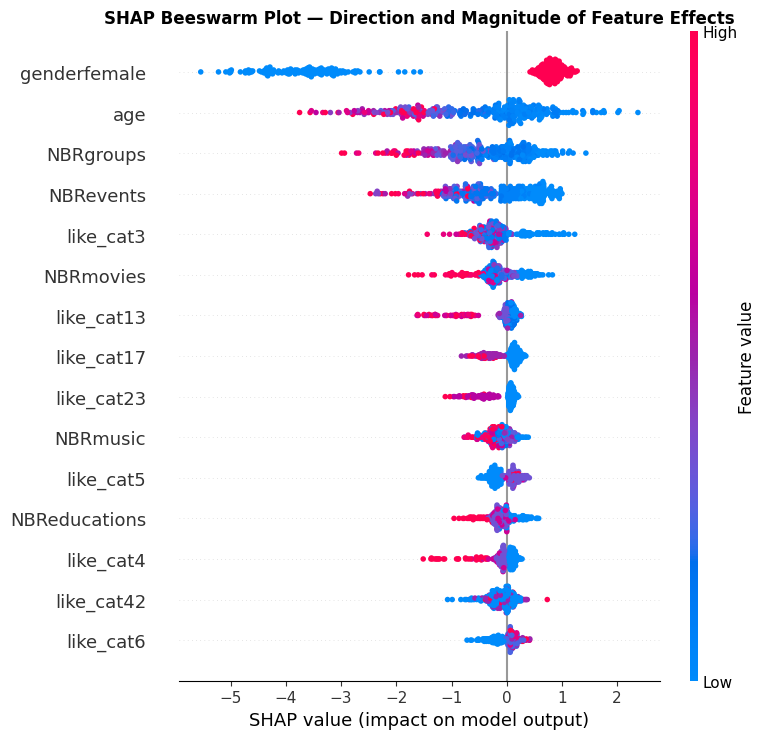

In [13]:
# Beeswarm plot: each dot = one test sample
# Colour = feature value (red = high difference, blue = low difference)
# x-axis position = SHAP value (positive = pushes prediction towards romantic relationship)
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP Beeswarm Plot — Direction and Magnitude of Feature Effects',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

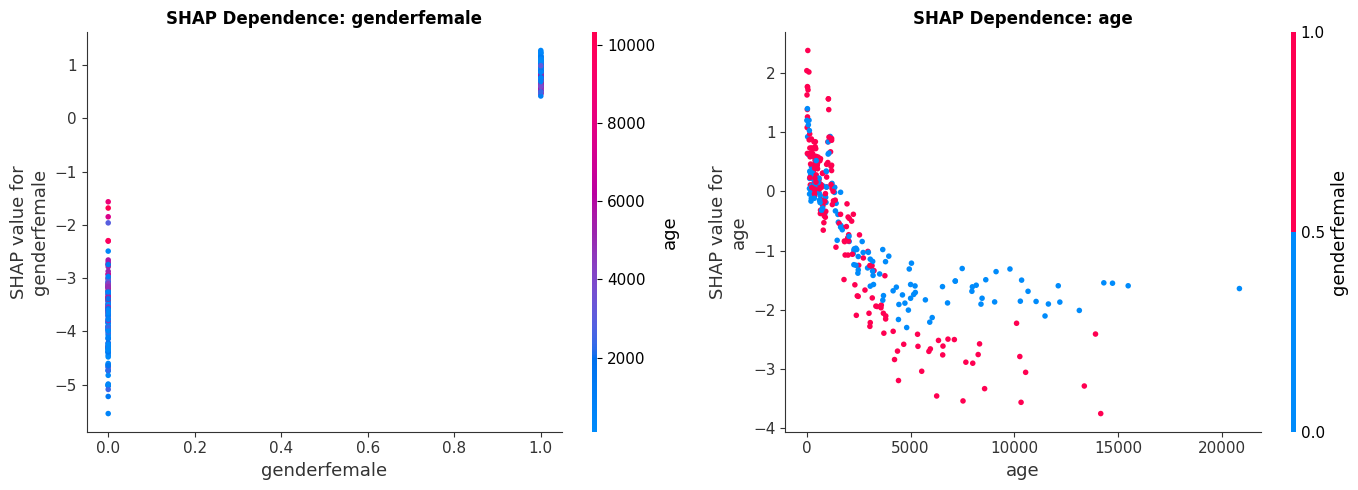

In [14]:
# SHAP dependence plots for the two most important features
# x-axis: raw feature value (pairwise absolute difference)
# y-axis: SHAP value (impact on prediction for that sample)
# Colour: automatically selected interaction variable (most correlated with residuals)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap.dependence_plot(top_features[0], shap_values, X_test,
                     ax=axes[0], show=False)
axes[0].set_title(f'SHAP Dependence: {top_features[0]}',
                  fontsize=12, fontweight='bold')

shap.dependence_plot(top_features[1], shap_values, X_test,
                     ax=axes[1], show=False)
axes[1].set_title(f'SHAP Dependence: {top_features[1]}',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Step 10: Interpretation and Key Findings

**Model performance**:

The XGBoost model achieves a strong AUC on the test set. This confirms that **pairwise differences in user attributes are genuinely predictive** of romantic relationships. 

**Key sociological findings (drawn from feature importance, PDPs, and SHAP)**:

1. **Gender difference** (`genderfemale`): Consistently the most important predictor across all three importance methods. When two friends differ in gender (difference = 1), the predicted probability of a romantic relationship is substantially higher. This reflects that romantic relationships in this dataset are predominantly heterosexual.

2. **Age similarity** (`age`): A smaller age gap between friends correlates with a higher probability of a romantic relationship. However, local variations around certain age differences can be spotted. 

3. **Agreement between methods**: Permutation importance and SHAP bar plots identify the same top features, increasing our confidence. The beeswarm plot additionally shows that gender and age effects are relatively consistent across individuals (low heterogeneity), suggesting these are robust, dataset-wide patterns rather than artefacts of a few outliers.